<div style="text-align: center;">
<h1> Pre-processing CPTAC – TCGA datasets </h1>    
</div>

The aim of this dataset is to pre-process CPTAC data for direct multiROMA usage. The steps include : quality checks, having genes in HGNC symbolism, filtering isoforms, and removing low-expression genes in transcriptomics data. The final dataset is saved as a parquet object, to preserve multi-indexing, and a matching gene set is generated and saved as well. \
Some intermediary datasets are also saved, as the matching gene ID steps is quite a lengthy operation (but not computationally costy). Having a saved GRCh38 gtf file is helpful to avoid relying on ENSEMBL API, and increase robustness. 

In [1]:
## Importing libraries
import mudata
mudata.set_options(pull_on_update=False)
import muon as mu
import pandas as pd
import numpy as np
import re

from sklearn.impute import KNNImputer
from multiroma_.utils import multiindex_df_to_mudata_extended 
from multiroma_.preprocessing import transcri_qc, proteomics_qc, convert_ensembl_to_hgnc, keep_highest_expressed_isoform

/opt/anaconda3/envs/ROMA_proj/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
# Importing the data
transcri_data=pd.read_csv("datasets/BRCA/BRCA_RNAseq_gene_RSEM_coding_UQ_1500_log2_Tumor.txt", sep="\t")
prot_data=pd.read_csv("datasets/BRCA/BRCA_proteomics_gene_abundance_log2_reference_intensity_normalized_Tumor.txt", sep="\t")

In [3]:
#Metadata
metadata=pd.read_csv("datasets/BRCA/BRCA_meta.txt", sep="\t")
metadata=metadata.set_index("idx")

## Quality checks

In [4]:
#Specifying gene IDs as index in the dataframe
transcri_data_c = transcri_data.set_index('idx')
prot_data_c = prot_data.set_index('idx')

Shape of the dataset:  (60669, 121)
Value range: 0.00 to 21.40
Number of zeros: 3958751
Number of NaNs: 0


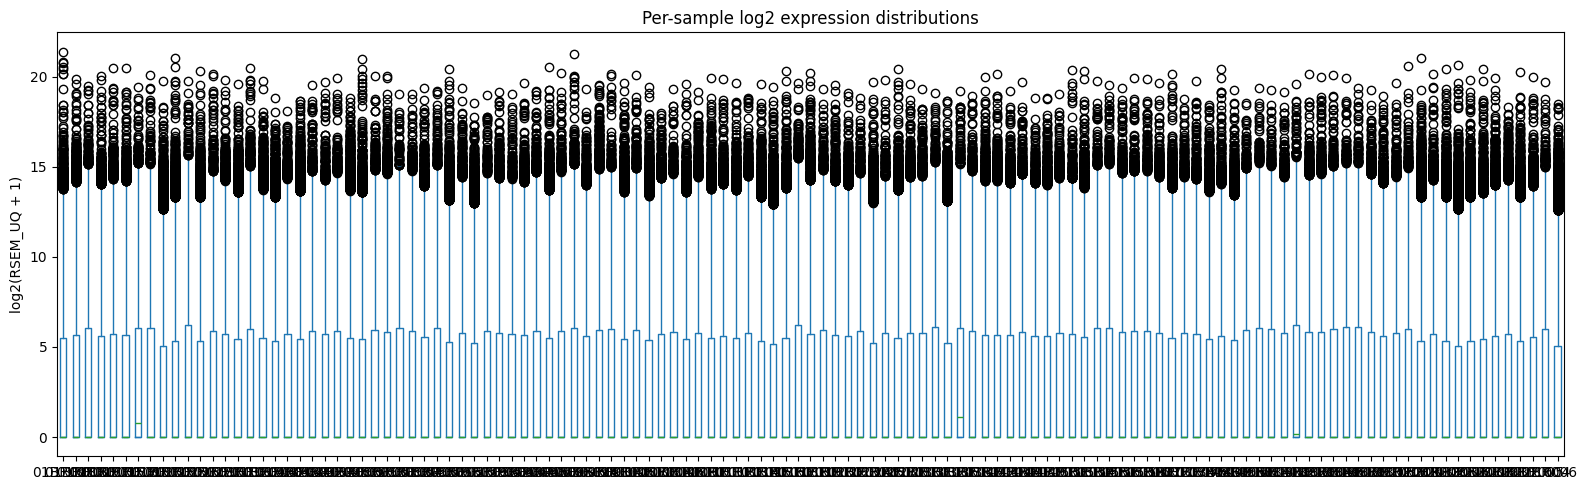

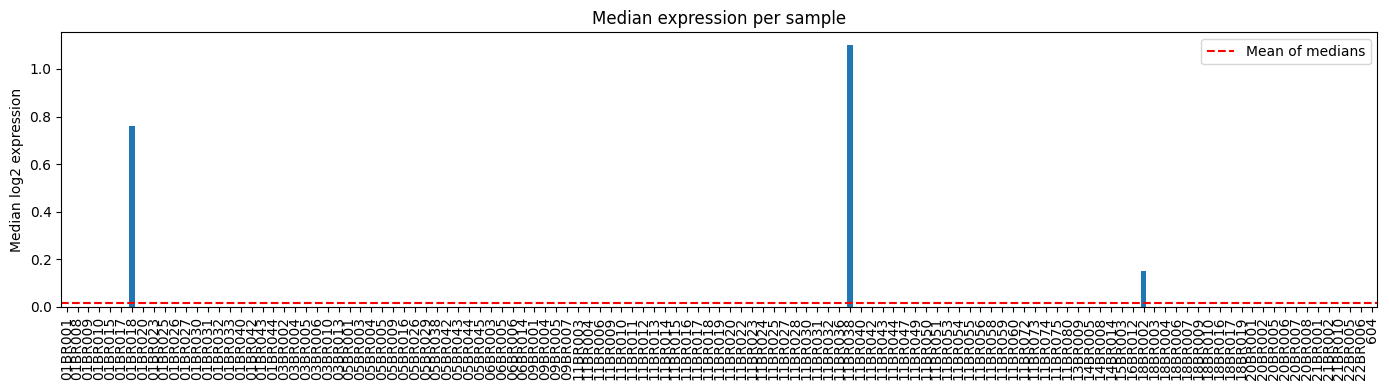

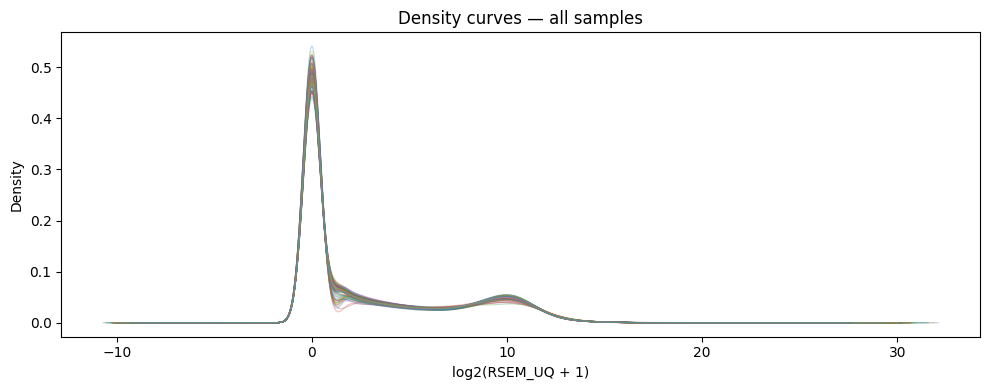

Genes with 0 in >50% of samples: 33705


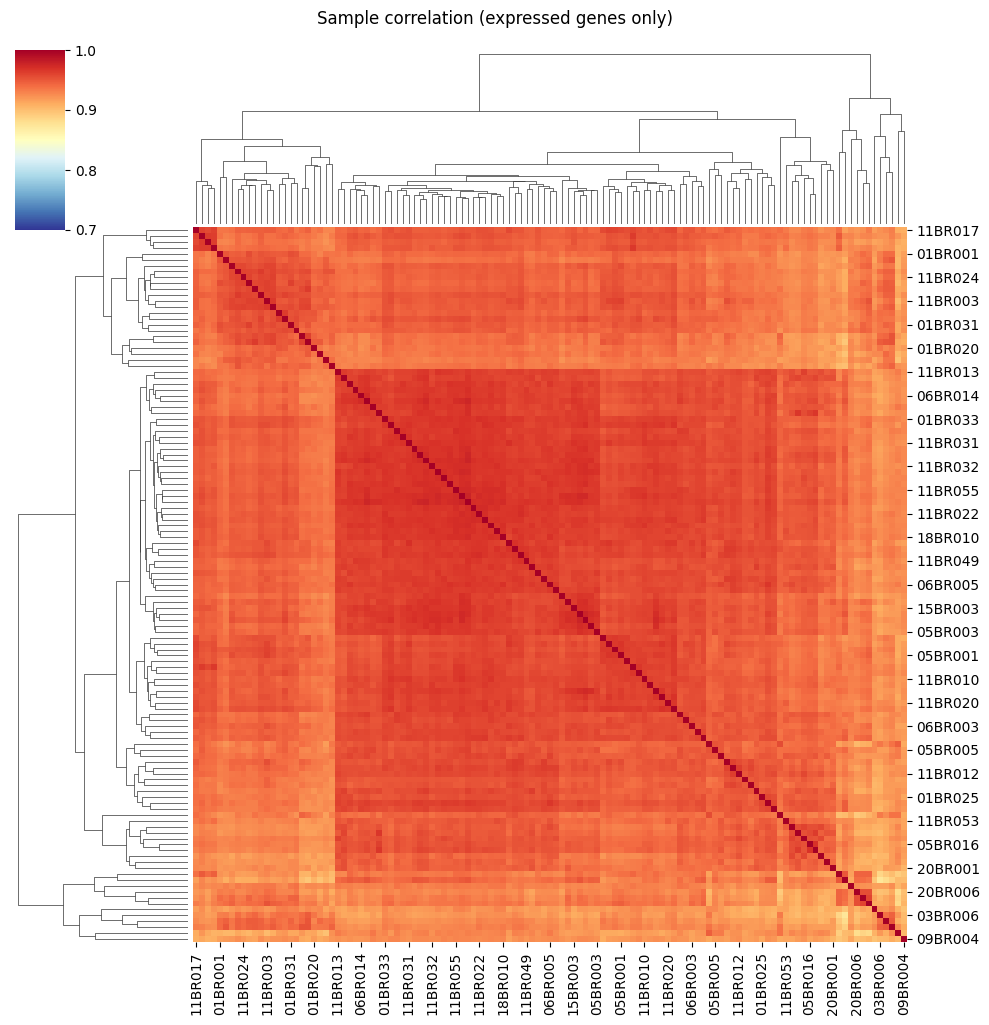

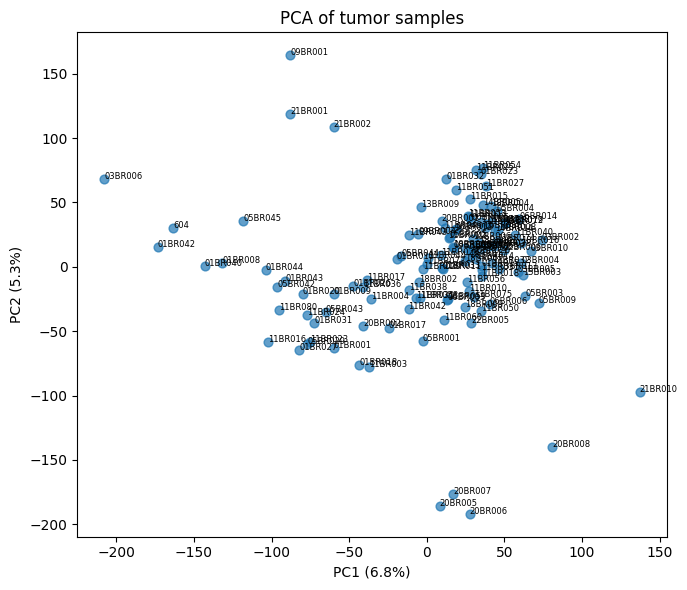

Global median: 0.0
Global IQR: 5.712
Samples with median < 1 (suspicious): 120


In [5]:
## Performing quality checks on transcriptomic data
transcri_qc(transcri_data_c)

Shape of the dataset:  (12022, 122)
Value range: 10.86 to 34.14
Data type:  float64    122
Name: count, dtype: int64
Number of NaNs: 260047


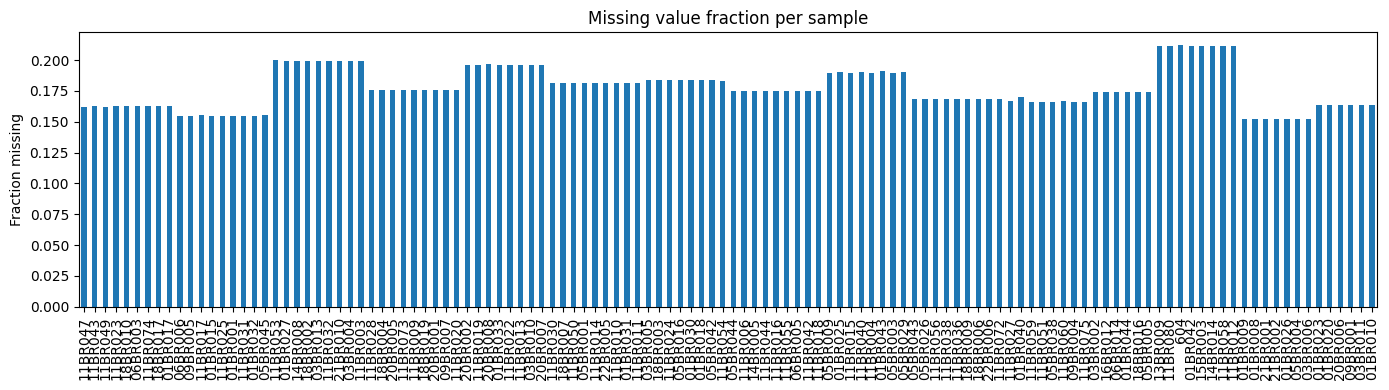

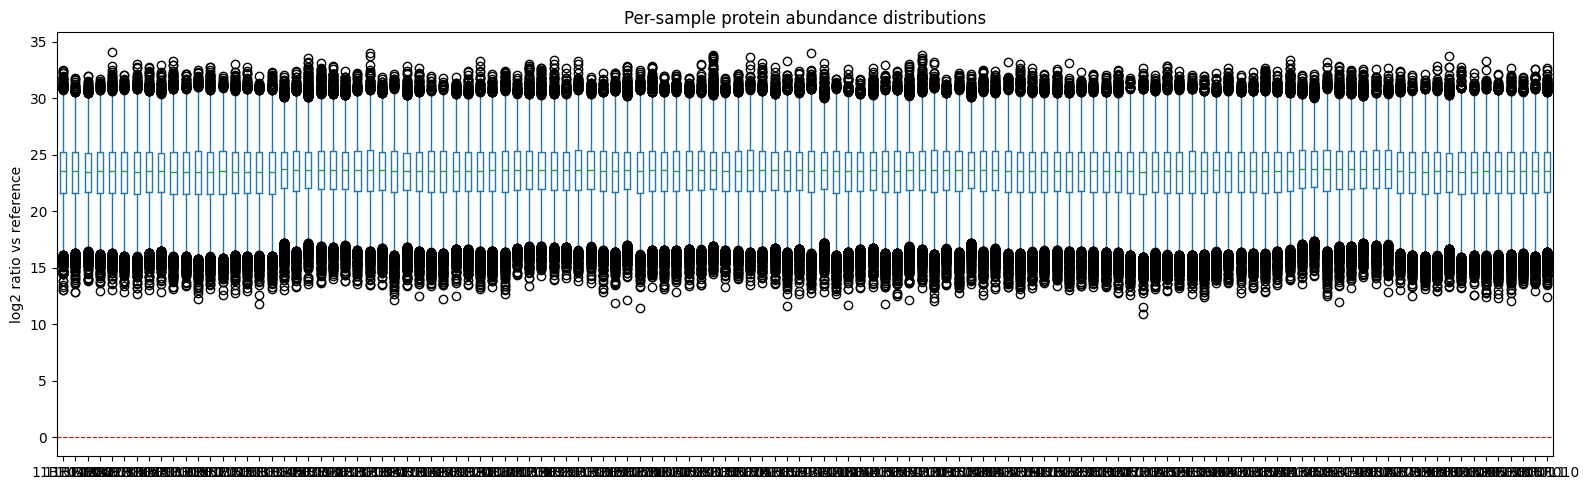

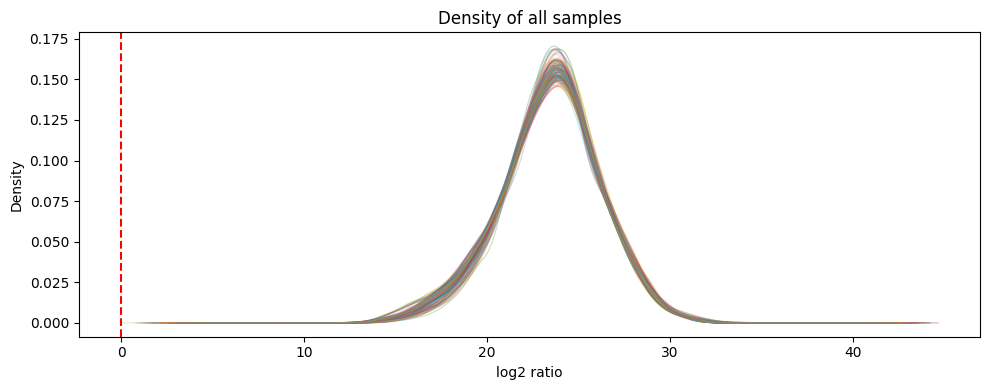

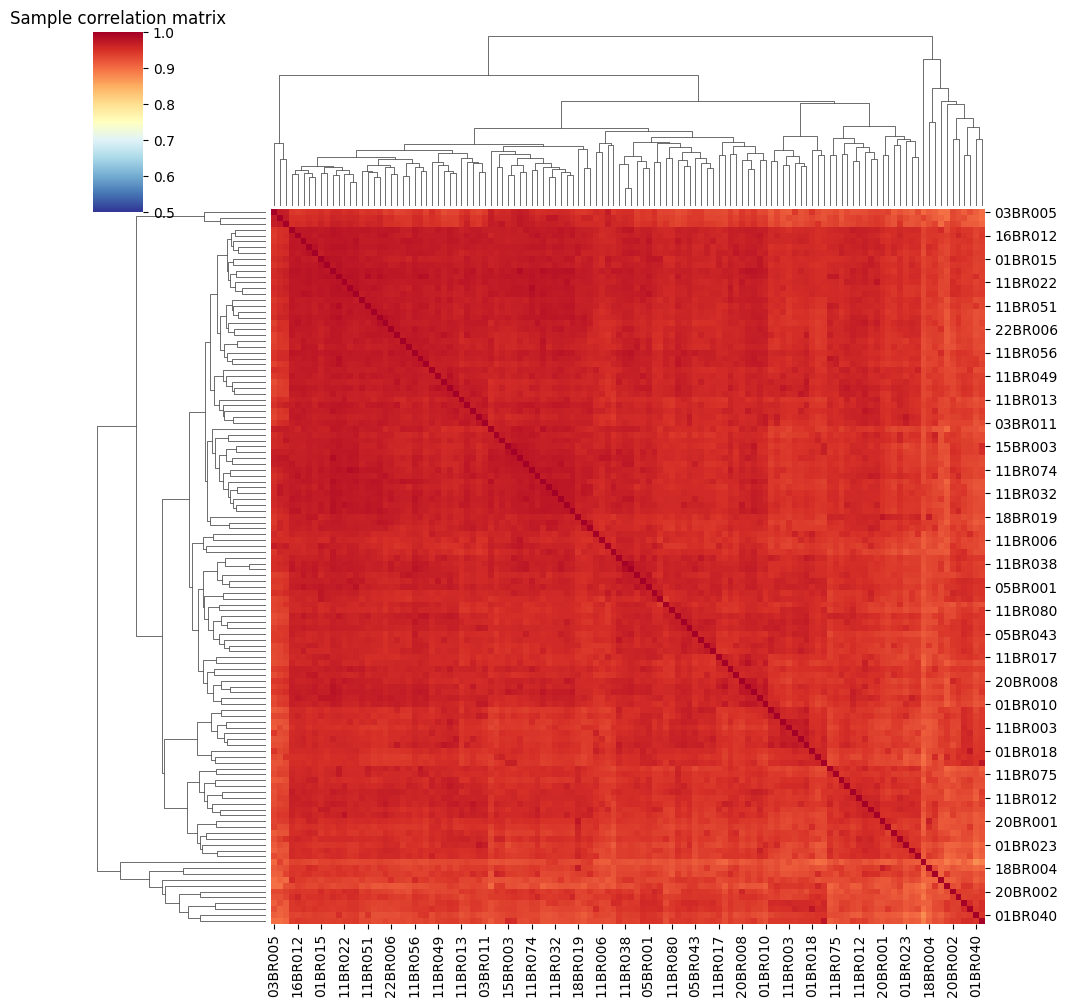

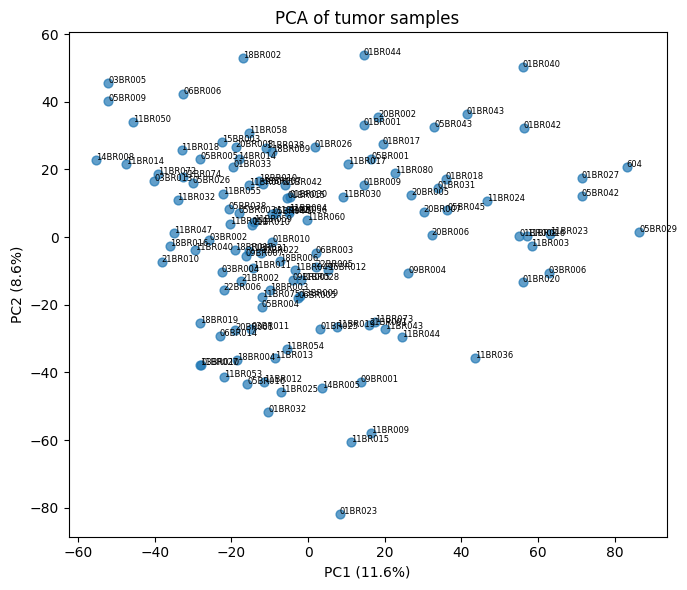

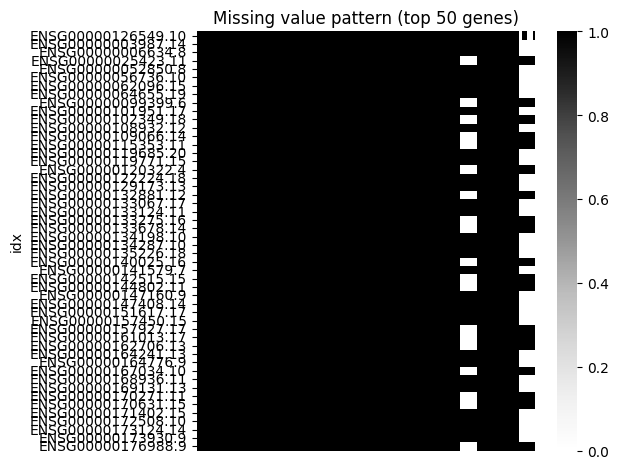

Global median: 23.597
Global IQR: 3.5106727245317018
Proteins with >50% missing: 2176
Samples with >30% missing: 0


In [6]:
# Performing quality checks on proteomic data
proteomics_qc(prot_data_c)

## Transcriptomics analysis

In this first step, focus is on curating and filtering transcriptomics data. 

In [7]:
# Convertiung gene names from ENSEMBL IDs to HGNC – lengthy step
n_transcri=transcri_data.copy() #duplicating dataset (good practice)
gene_names=convert_ensembl_to_hgnc(transcri_data["idx"], get_biotype=True, gtf_path="datasets/Homo_sapiens.GRCh38.111.gtf")

#!genome-build GRCh38.p14
#!genome-version GRCh38
#!genome-date 2013-12
#!genome-build-accession GCA_000001405.29
#!genebuild-last-updated 2023-07
Loading GTF from multiroma/multiroma_/datasets/Homo_sapiens.GRCh38.111.gtf...


Input sequence provided is already in string format. No operation performed


GTF loaded: 63241 genes, assembly info above.
Querying mygene for 60624 Ensembl IDs...


30 input query terms found dup hits:	[('ENSG00000228044', 2), ('ENSG00000262352', 3), ('ENSG00000188092', 2), ('ENSG00000278932', 3), ('E
1323 input query terms found no hit:	['ENSG00000287368', 'ENSG00000273370', 'ENSG00000286111', 'ENSG00000260090', 'ENSG00000228008', 'ENS


Falling back for 15308 unmapped IDs...
  GTF resolved 174/15308 fallback IDs. 15134 still unmapped → trying REST API...
Fetching biotype information...
  GTF resolved 60337 biotypes. 287 still needed → trying REST API...

Mapping complete: 45529/60669 genes mapped (75.0%)


In [8]:
#Adding the new gene names as index
a=[]
for i in gene_names["hgnc_symbol"]:
    if i != None:
        clean = re.sub(r"^(rs_|pp_)+", "", i)  # remove ALL leading rs_/pp_ prefixes
        a.append(f"rs_{clean}")                # adding rs_ prefix for all transcriptomic data
    else:
        a.append(None)
gene_names["hgnc_symbol"]=a
n_transcri["idx"]=gene_names["hgnc_symbol"]

#Retrieving biotype information
n_transcri["biotype"]=gene_names["biotype"]

#Dropping genes with no HGNC match
n_transcri = n_transcri.dropna(subset=["idx"]).set_index("idx")

# Keeping only protein-coding RNAs
n_transcri = n_transcri[n_transcri["biotype"]== "protein_coding"].copy()

In [9]:
# Avoid duplicates – keeping only the best isoforms per gene
## Warning : drops the "biotype" column
n_transcri = keep_highest_expressed_isoform(n_transcri)
n_transcri

,01BR001,01BR008,01BR009,01BR010,01BR015,01BR017,01BR018,01BR020,01BR023,01BR025,...,20BR005,20BR006,20BR007,20BR008,21BR001,21BR002,21BR010,22BR005,22BR006,604
idx,,,,,,,,,,,,,,,,,,,,,
rs_A1BG,3.8942,3.2842,5.6472,4.6933,4.4784,2.6751,3.2518,5.4872,5.1877,5.9189,...,4.3319,3.3779,3.3417,2.0413,3.3022,0.0000,3.4413,3.7222,3.2683,0.0000
rs_A1CF,0.0000,2.9307,0.0000,0.0000,2.0149,1.2611,1.2669,0.0000,0.0000,0.0000,...,3.3854,1.3505,0.0000,2.0300,2.4476,0.0000,1.3935,4.3018,1.2846,0.0000
rs_A2M,13.3423,13.5227,14.5028,13.1126,14.1722,14.0721,13.6121,13.9030,12.5222,13.6322,...,14.2422,13.7822,14.4422,14.7522,13.7528,14.5524,14.5023,14.2522,14.7521,12.7423
rs_A2ML1,5.2758,10.6017,10.3215,5.4882,3.8814,9.2712,10.1916,4.9258,0.0000,4.3018,...,11.1319,10.5217,10.5917,2.4982,2.4476,1.4691,0.0000,5.9492,1.9476,10.5617
rs_A3GALT2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,2.1759,0.0000,0.0000,0.0000,1.4883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rs_ZYG11A,7.4766,9.0997,4.4102,8.7491,5.6875,8.7508,9.2611,8.6479,5.1368,7.3272,...,7.7585,7.5380,5.8697,7.0663,7.6138,6.0559,4.5748,8.0692,6.9571,9.0403
rs_ZYG11B,10.2716,8.9393,9.7208,9.7509,10.7518,10.1516,10.5017,10.0111,9.3509,10.1115,...,11.2719,10.9618,11.4019,10.9018,9.0495,9.5710,11.1519,10.0015,10.2916,9.1404
rs_ZYX,11.0419,11.8624,11.4022,12.8625,11.0619,11.0218,10.5717,11.0321,8.8604,10.9118,...,10.0215,8.5601,10.1115,10.1715,12.0825,12.3222,8.8904,10.5517,12.5920,12.2022


Shape of the dataset:  (19437, 121)
Value range: 0.00 to 21.40
Number of zeros: 335260
Number of NaNs: 0


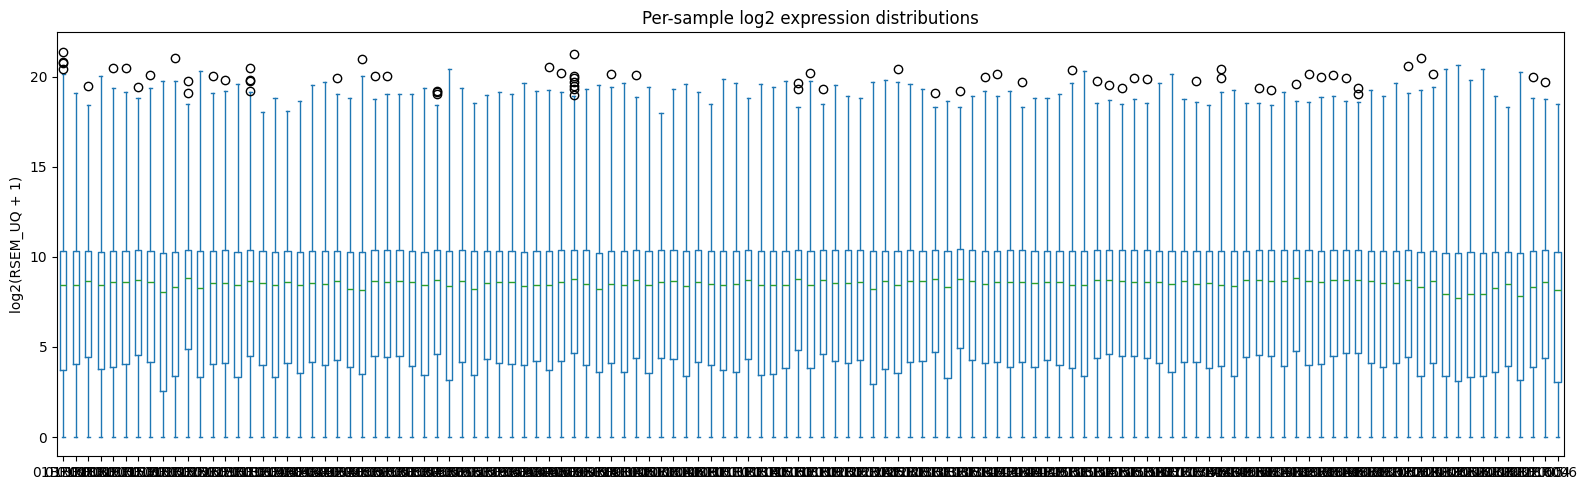

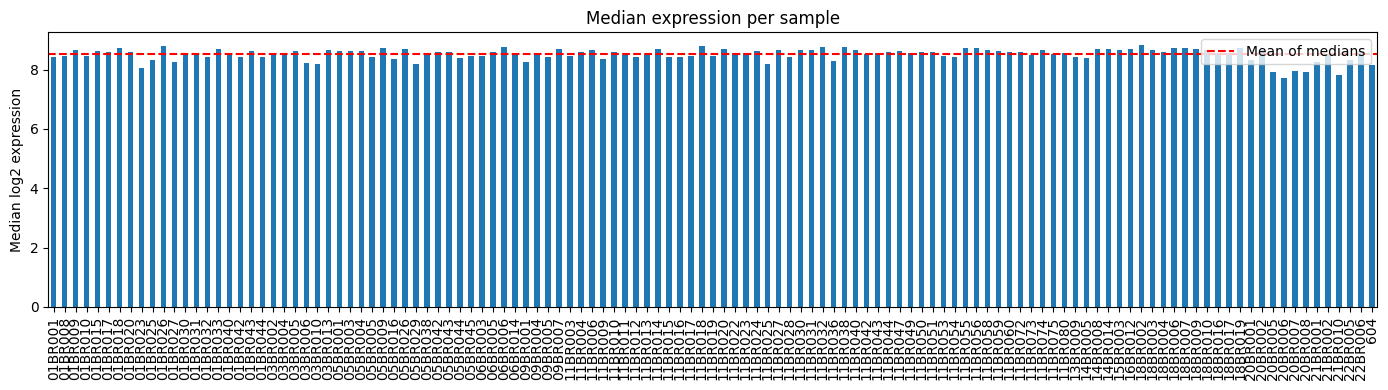

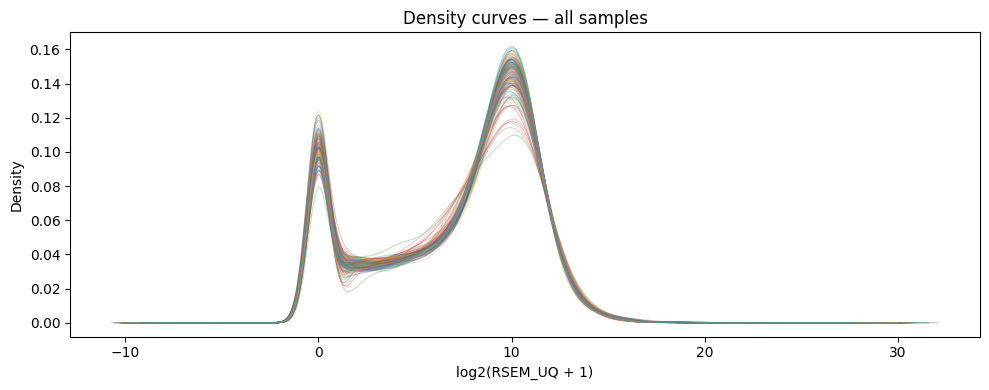

Genes with 0 in >50% of samples: 2729


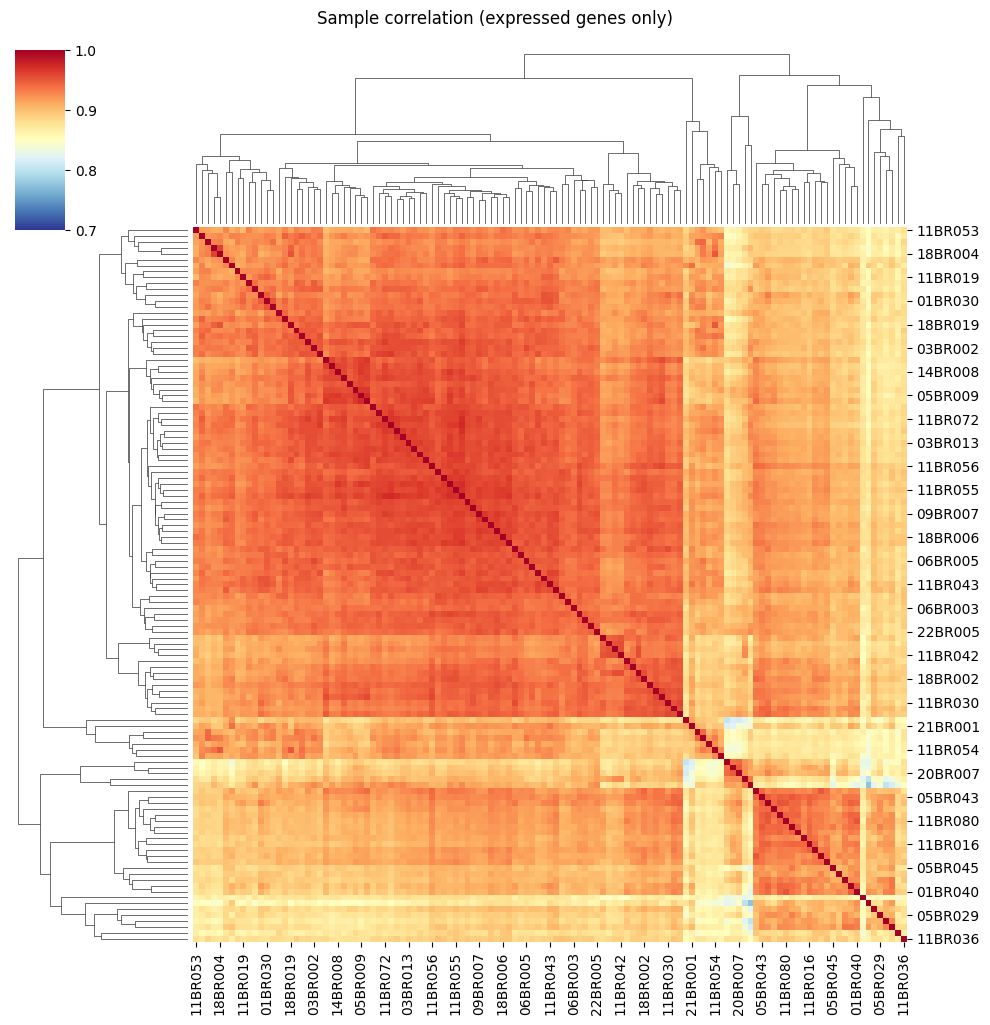

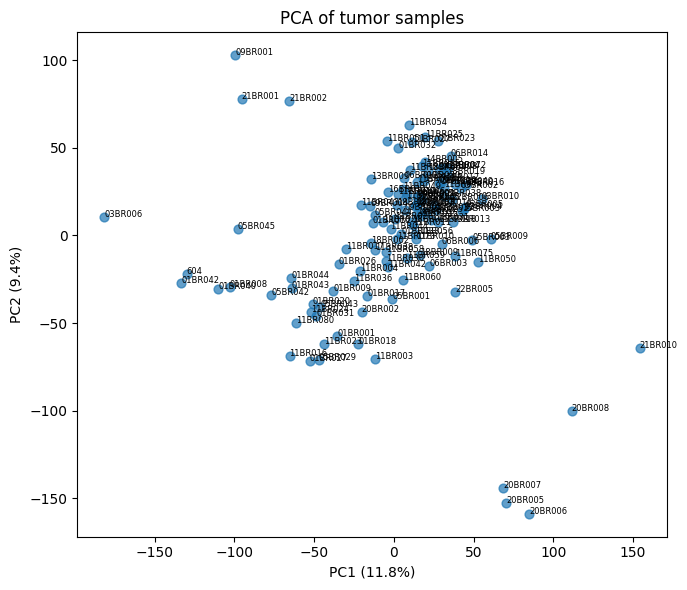

Global median: 8.531
Global IQR: 6.353
Samples with median < 1 (suspicious): 0


In [10]:
#Quality check
transcri_qc(n_transcri)

In [11]:
#Filtering low-expression genes (genes with no expression in more than 50% of samples)
zero_frac = (n_transcri == 0).mean(axis=1)
filtered_n_transcri=n_transcri[zero_frac < 0.5].copy()
filtered_n_transcri

,01BR001,01BR008,01BR009,01BR010,01BR015,01BR017,01BR018,01BR020,01BR023,01BR025,...,20BR005,20BR006,20BR007,20BR008,21BR001,21BR002,21BR010,22BR005,22BR006,604
idx,,,,,,,,,,,,,,,,,,,,,
rs_A1BG,3.8942,3.2842,5.6472,4.6933,4.4784,2.6751,3.2518,5.4872,5.1877,5.9189,...,4.3319,3.3779,3.3417,2.0413,3.3022,0.0000,3.4413,3.7222,3.2683,0.0000
rs_A1CF,0.0000,2.9307,0.0000,0.0000,2.0149,1.2611,1.2669,0.0000,0.0000,0.0000,...,3.3854,1.3505,0.0000,2.0300,2.4476,0.0000,1.3935,4.3018,1.2846,0.0000
rs_A2M,13.3423,13.5227,14.5028,13.1126,14.1722,14.0721,13.6121,13.9030,12.5222,13.6322,...,14.2422,13.7822,14.4422,14.7522,13.7528,14.5524,14.5023,14.2522,14.7521,12.7423
rs_A2ML1,5.2758,10.6017,10.3215,5.4882,3.8814,9.2712,10.1916,4.9258,0.0000,4.3018,...,11.1319,10.5217,10.5917,2.4982,2.4476,1.4691,0.0000,5.9492,1.9476,10.5617
rs_A4GALT,8.4795,6.8276,8.0461,6.6573,7.8289,7.4087,8.9509,6.0110,8.2193,8.5801,...,4.7928,4.5999,4.7350,5.1298,7.9356,7.9981,4.2350,8.5801,8.0698,6.6510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rs_ZYG11A,7.4766,9.0997,4.4102,8.7491,5.6875,8.7508,9.2611,8.6479,5.1368,7.3272,...,7.7585,7.5380,5.8697,7.0663,7.6138,6.0559,4.5748,8.0692,6.9571,9.0403
rs_ZYG11B,10.2716,8.9393,9.7208,9.7509,10.7518,10.1516,10.5017,10.0111,9.3509,10.1115,...,11.2719,10.9618,11.4019,10.9018,9.0495,9.5710,11.1519,10.0015,10.2916,9.1404
rs_ZYX,11.0419,11.8624,11.4022,12.8625,11.0619,11.0218,10.5717,11.0321,8.8604,10.9118,...,10.0215,8.5601,10.1115,10.1715,12.0825,12.3222,8.8904,10.5517,12.5920,12.2022


Shape of the dataset:  (16708, 121)
Value range: 0.00 to 21.40
Number of zeros: 60914
Number of NaNs: 0


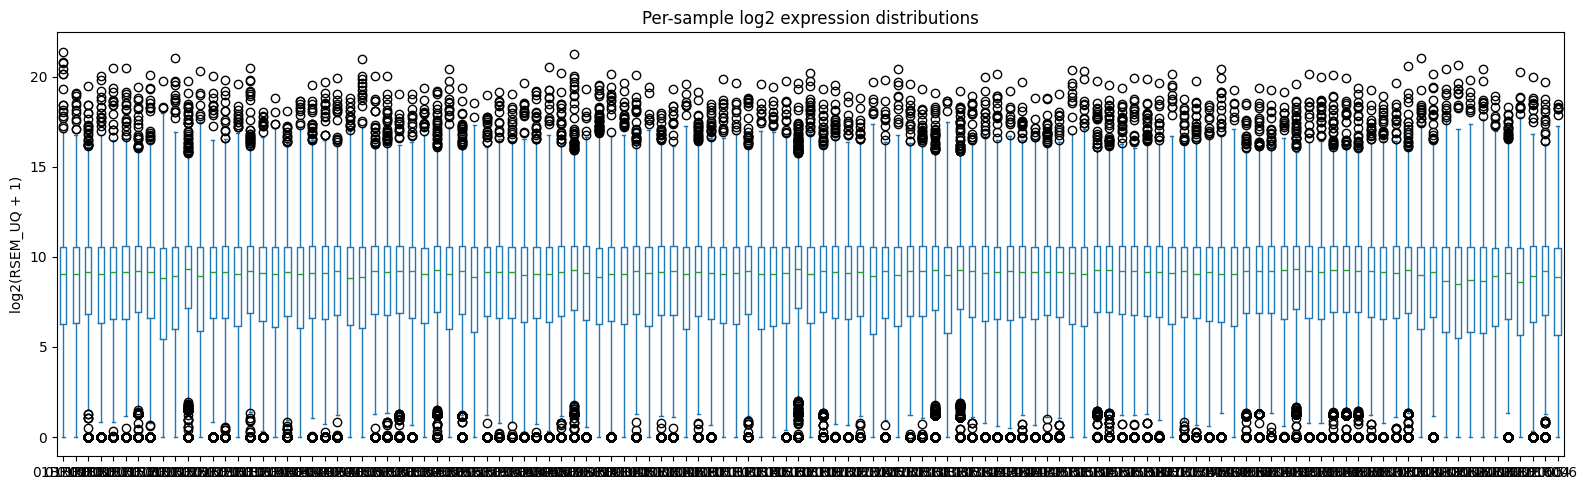

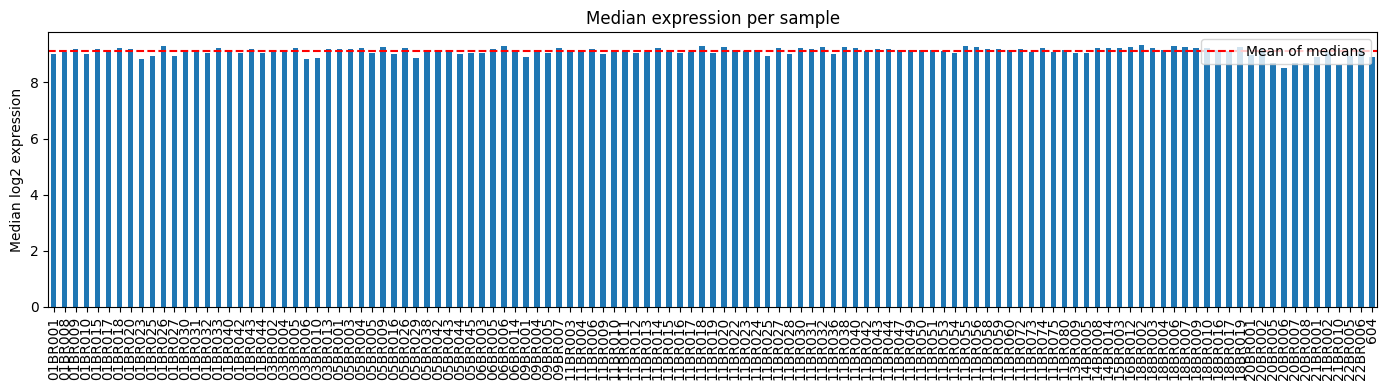

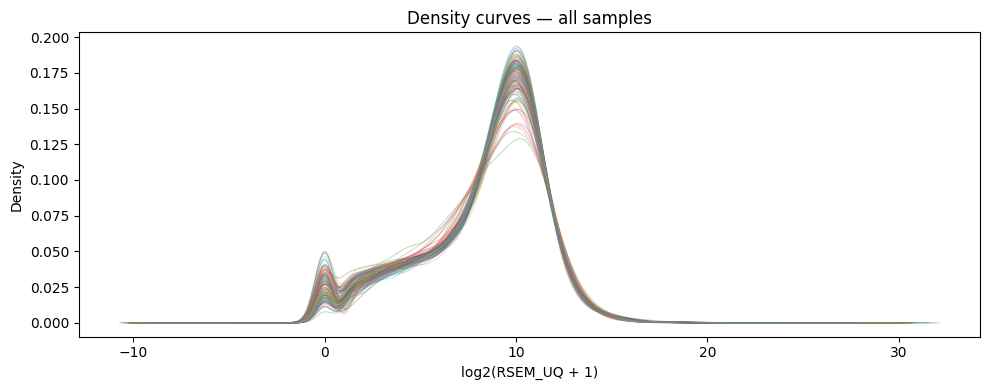

Genes with 0 in >50% of samples: 0


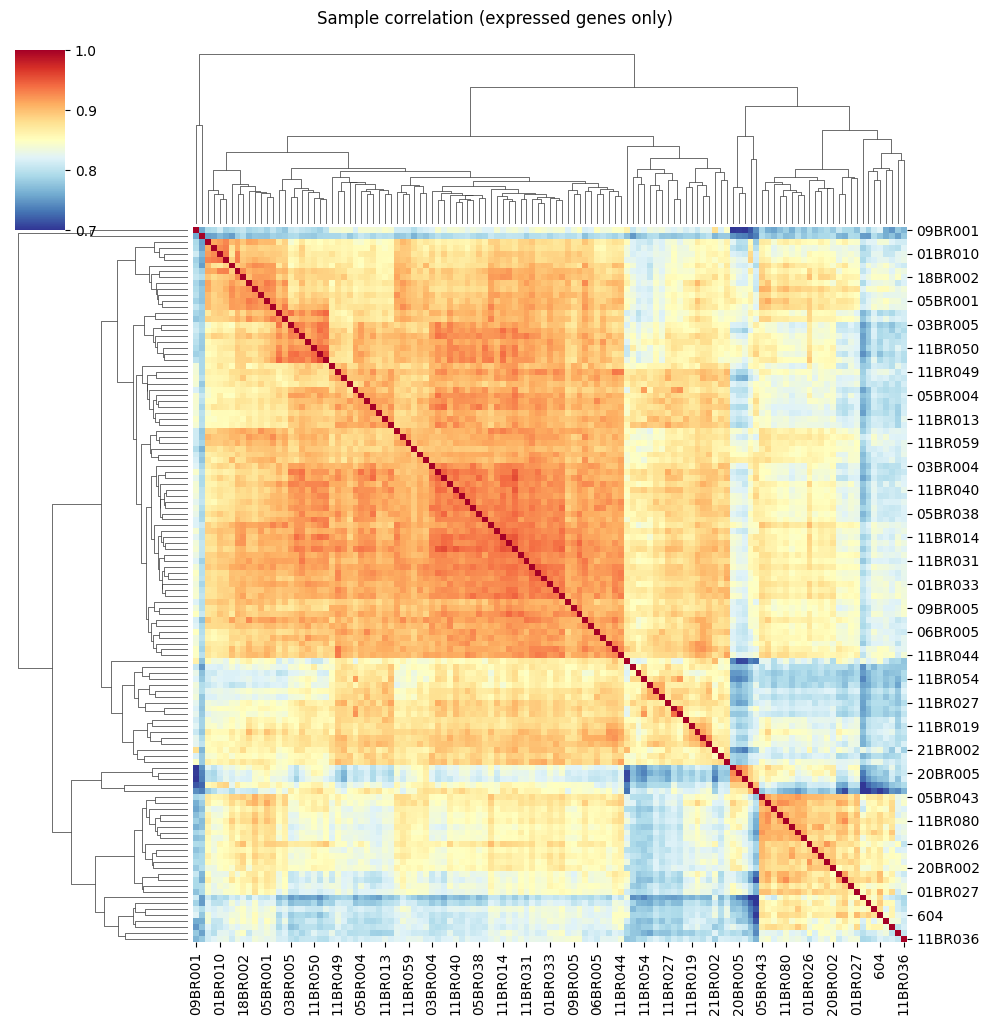

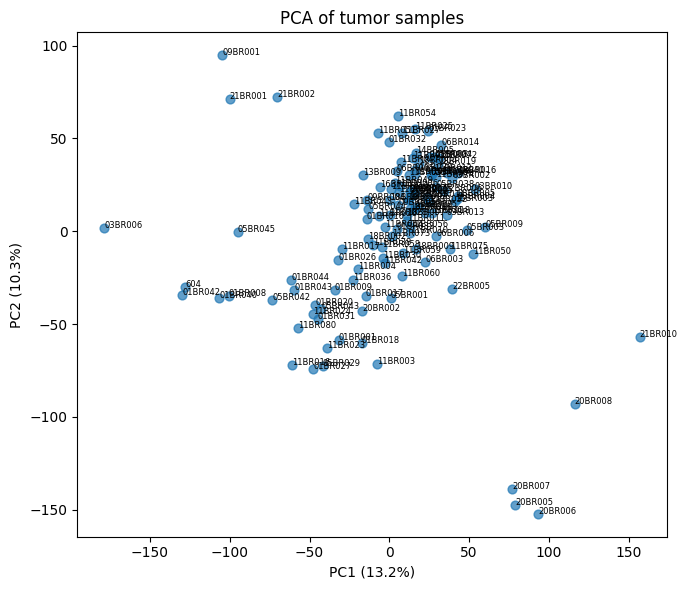

Global median: 9.121
Global IQR: 4.062
Samples with median < 1 (suspicious): 0


In [12]:
# Quality checks
transcri_qc(filtered_n_transcri)

In [13]:
filtered_n_transcri=filtered_n_transcri.T
#Saving 
filtered_n_transcri.to_csv("datasets/BRCA/BRCA_dataset_RNA_seq_normalised_preprocessed.csv")

## Proteomics analysis

In this second step, focus is on curating and filtering transcriptomics data. 

In [14]:
# Matching ENSEMBL IDs to HGNC symbols
n_prot=prot_data.copy()
gene_names=convert_ensembl_to_hgnc(prot_data["idx"], gtf_path="datasets/Homo_sapiens.GRCh38.111.gtf")

#!genome-build GRCh38.p14
#!genome-version GRCh38
#!genome-date 2013-12
#!genome-build-accession GCA_000001405.29
#!genebuild-last-updated 2023-07
Loading GTF from multiroma/multiroma_/datasets/Homo_sapiens.GRCh38.111.gtf...


Input sequence provided is already in string format. No operation performed


GTF loaded: 63241 genes, assembly info above.
Querying mygene for 12022 Ensembl IDs...


5 input query terms found no hit:	['ENSG00000130723', 'ENSG00000215271', 'ENSG00000263264', 'ENSG00000148362', 'ENSG00000112096']


Falling back for 9 unmapped IDs...
  GTF resolved 1/9 fallback IDs. 8 still unmapped → trying REST API...
Fetching biotype information...
  GTF resolved 12018 biotypes. 4 still needed → trying REST API...

Mapping complete: 12014/12022 genes mapped (99.9%)


In [15]:
# Adding the new gene symbols as index
a=[]
for i in gene_names["hgnc_symbol"]:
    if i!=None:
        a.append(f"pp_{i}") # adding pp_ prefix for all transcriptomic data
    else:
        a.append(None)
gene_names["hgnc_symbol"]=a
n_prot["idx"]=gene_names["hgnc_symbol"]

#Dropping genes with no HGNC match
n_prot = n_prot.dropna(subset=["idx"]).set_index("idx")

In [16]:
#Getting proportion of missing values per sample
nan_positions=np.isnan(n_prot.T)
prop_nan=np.sum(nan_positions,axis=1)/nan_positions.shape[1]

In [17]:
#Removing missing values with KNN Impute
KNN=KNNImputer(missing_values=np.nan,         #placeholder for the missing values
               n_neighbors=5,              #number of neighboring samples to use
               weights='uniform',          #Weight function used in prediction.
               metric='nan_euclidean',     #Distance metric for searching neighbors
               copy=True,                 #imputation done in-place
               add_indicator=False,        #predictive estimator accounts for missingness despite imputation
               keep_empty_features=False)  #features that consist exclusively of missing values returned with value =0
n_prot_knn=KNN.fit_transform(n_prot)
n_prot_knn=pd.DataFrame(n_prot_knn, index=n_prot.index, columns=n_prot.columns)
n_prot_knn

,11BR047,11BR043,11BR049,11BR023,18BR010,06BR003,11BR074,18BR017,01BR017,06BR006,...,21BR002,01BR026,05BR004,03BR006,01BR023,01BR020,20BR006,09BR001,03BR011,01BR010
idx,,,,,,,,,,,,,,,,,,,,,
pp_TSPAN6,23.536230,21.667211,22.484736,22.634519,22.246917,24.053366,21.543035,22.985591,21.686800,22.265812,...,21.685412,22.014363,21.589823,23.282217,21.798901,21.420225,22.408042,22.857560,22.819791,24.891752
pp_TNMD,17.041527,17.003609,17.227036,17.103698,17.191054,17.000564,16.988987,16.740443,17.325210,18.030836,...,17.042925,17.939179,16.880262,17.394368,16.916788,17.306406,17.012917,16.978469,16.933618,17.349284
pp_DPM1,26.037709,25.651781,25.980302,25.225479,25.992452,25.785667,26.078246,25.913642,25.903479,25.860100,...,26.059036,25.841827,26.011085,26.057347,26.139319,25.616726,25.452848,25.715871,26.004246,26.483965
pp_SCYL3,23.574738,23.921688,23.894719,23.089085,23.465635,24.055217,23.713464,23.791090,23.472496,23.825453,...,24.199771,23.536011,24.002968,23.541033,23.737002,23.462971,23.762129,24.042554,24.305859,24.364289
pp_FIRRM,18.228407,18.947025,19.422939,19.522822,18.471002,18.339678,18.226444,19.573102,19.328173,18.702945,...,19.221560,18.987920,18.474834,19.222270,18.664169,18.550852,18.786632,18.717807,18.831380,18.832457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pp_EEF1AKMT4,19.129039,20.137307,19.716031,20.039873,19.898370,19.615347,19.448184,19.484873,21.170820,19.643035,...,19.001550,21.328326,19.201372,19.237348,19.231464,19.865030,20.457982,19.932347,19.574225,19.900984
pp_MIURF,21.648042,21.996900,21.068699,21.622513,21.418864,22.404485,21.881016,22.181243,21.768897,23.025628,...,21.426329,21.752081,21.914948,22.460532,22.124800,21.700846,21.913802,21.675866,21.631067,22.181430
pp_LOC128706665,21.818995,23.093035,22.134389,22.827876,22.540802,22.971954,22.860124,22.439745,23.095670,23.011286,...,22.239494,22.741532,22.139459,22.323698,22.163160,23.062634,22.663729,21.749961,22.695192,22.786296


Shape of the dataset:  (12014, 122)
Value range: 10.86 to 34.14
Data type:  float64    122
Name: count, dtype: int64
Number of NaNs: 0


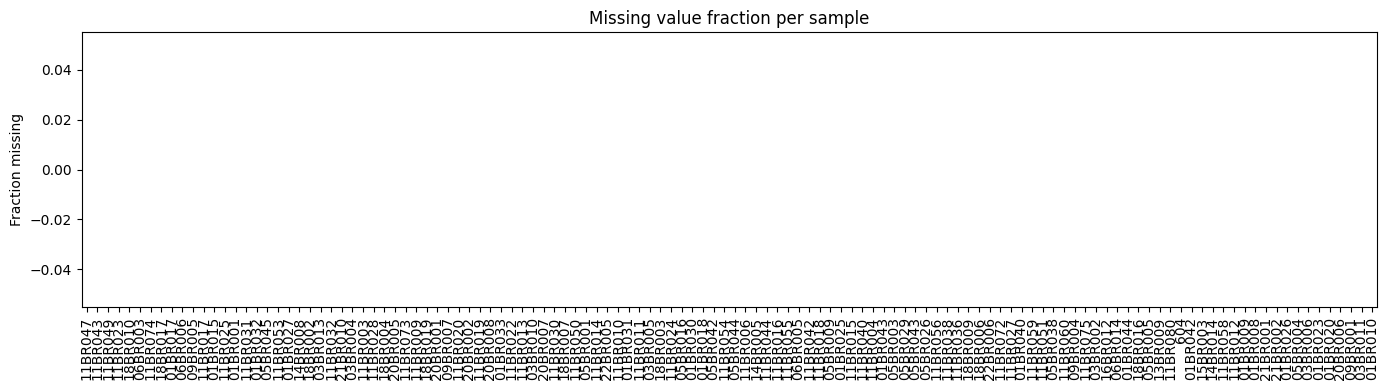

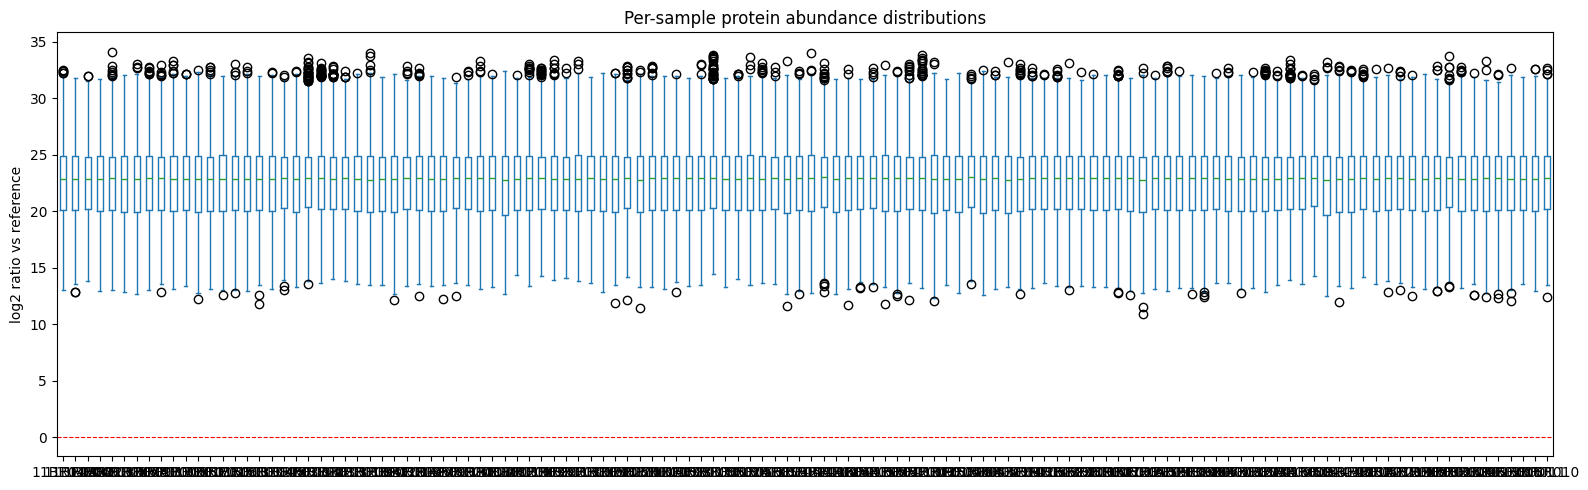

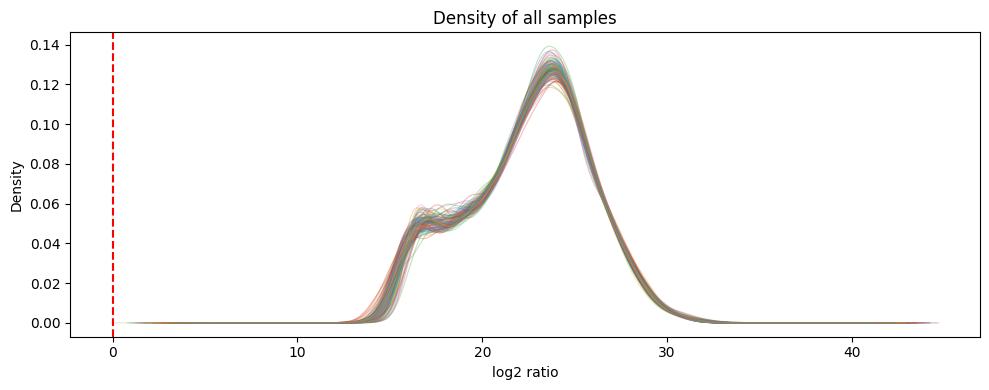

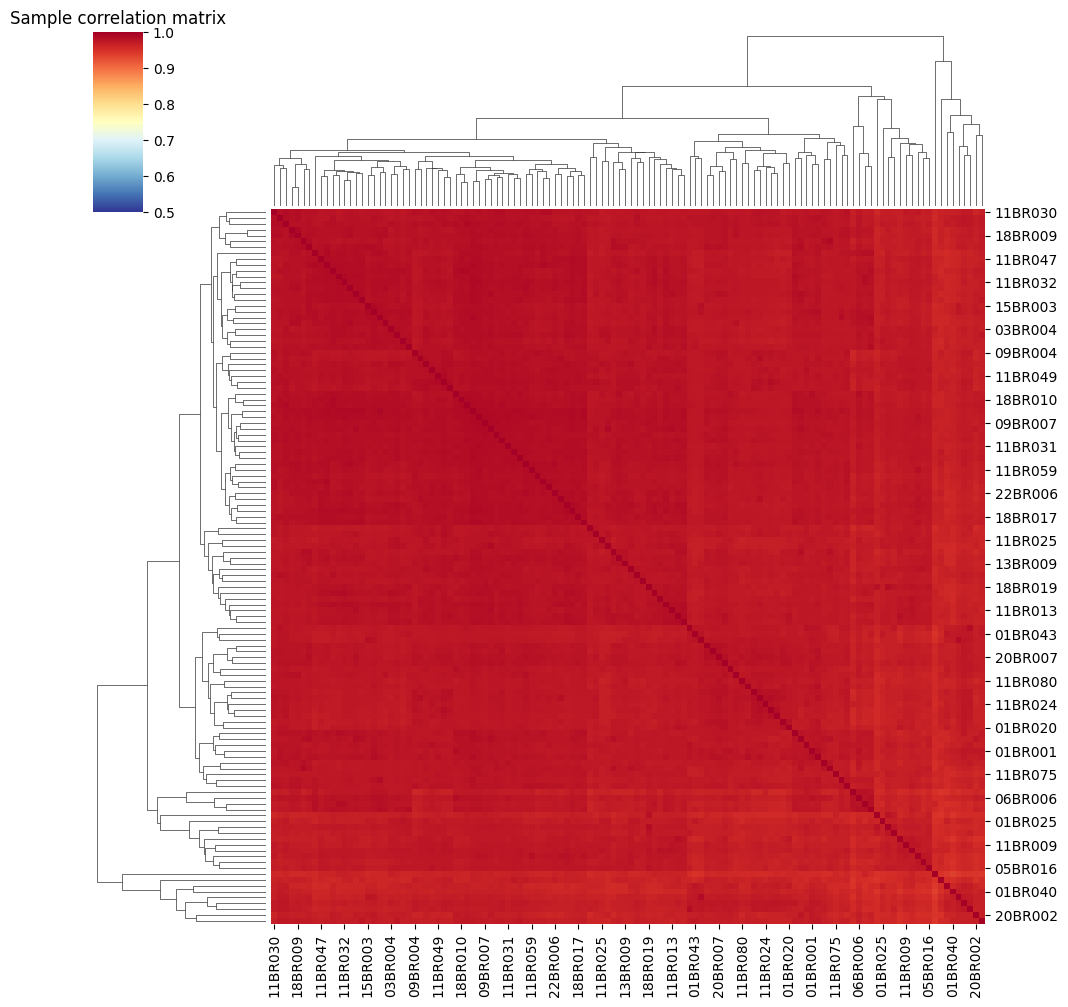

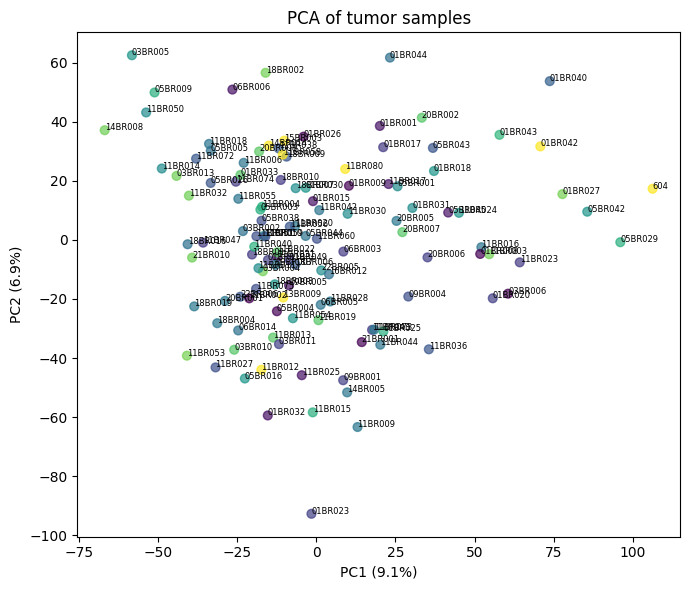

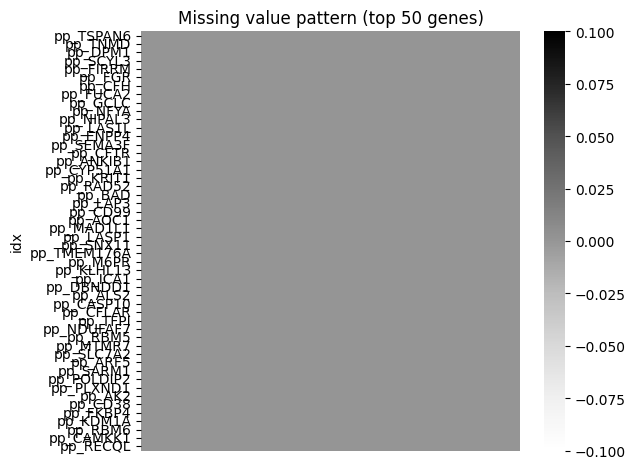

Global median: 22.9
Global IQR: 4.787705427840777
Proteins with >50% missing: 0
Samples with >30% missing: 0


In [18]:
proteomics_qc(n_prot_knn, color_pc=True, color_code=prop_nan)

In [19]:
n_prot_knn=n_prot_knn.T
#Saving
n_prot_knn.to_csv("datasets/BRCA/BRCA_dataset_proteins_KNNImpute_normalised_preprocessed.csv")

## Creating the concatenated dataset 

To run multiROMA, a dataset concatenating the different omics data is required. This dataset must be multi-indexed.

In [20]:
modalities=["rna", "prot"]

In [21]:
data=pd.concat(
    [filtered_n_transcri,n_prot_knn],     #transposition to have genes as columns
    axis=1,                      # concatenation on row axis
    keys=["rna", "prot"],   # first index level – the different types of omics data
    join="inner"                 # to keep only samples that are in both datasets
)

#Checking that no duplicates left, and for the size of the dataset
print(f"Any duplicates left: {data.columns.duplicated().any()}") 
print(f"New shape: {data.shape}")

# Creating new mudata objects
combined_knn = multiindex_df_to_mudata_extended(data, feature_level=0, name_level=1, init_annot=None)
combined_knn

Any duplicates left: False
New shape: (121, 28722)


MuData object with n_obs × n_vars = 121 × 28722
  2 modalities
    rna:	121 x 16708
      obs:	'celltype'
    prot:	121 x 12014
      obs:	'celltype'

In [22]:
#Saving
combined_knn.write("datasets/BRCA/combined_BRCA_dataset_rna_and_prot_preprocessed.h5mu")

## Creating the gene sets

Here, we make new gene sets, matching our prefixes for genes HGNC symbols. Genes sets are created from already existing hallmark gene set (as .gmt file) : other kind of gmt files could be used.

In [24]:
from collections import defaultdict

#Specifying input and output files
gmt_input = "genesets/h.all.v2023.1.Hs.symbols.gmt"
gmt_output = "genesets/BRCA_h.all.v2023.1.Hs.symbols_expanded.gmt" ##

# Get data genes (columns)
dataset_genes = data.columns.get_level_values(1)

#Buiding gene map : removing prefix, and gathering HGNC symbols
gene_map = defaultdict(list)

for g in dataset_genes:
    if "_" in g:
        prefix, gene = g.split("_", 1)
        gene_map[gene].append(g)

#Reading existing gmt
gene_sets = []

with open(gmt_input) as f:
    for line in f:
        parts = line.strip().split("\t")
        set_name = parts[0]
        description = parts[1]
        genes = parts[2:]
        gene_sets.append((set_name, description, genes))

#Creating the new set genes by matching existing genes and adding the right prefix
new_gene_sets = []

for set_name, description, genes in gene_sets:
    
    expanded_genes = []
    
    for gene in genes:
        if gene in gene_map:
            expanded_genes.extend(gene_map[gene])
    
    if expanded_genes:
        new_gene_sets.append(
            (set_name, description, expanded_genes)
        )

#Creating the new gene set
with open(gmt_output, "w") as f:
    for set_name, description, genes in new_gene_sets:
        line = "\t".join([set_name, description] + genes)
        f.write(line + "\n")

#new_gene_sets